In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, auc
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier


# Load Data

In [26]:
# 載入 iris 資料集
iris = load_iris()
df = pd.DataFrame(iris["data"], columns=iris["feature_names"])
df["target"] = iris["target"]

# 預處理

In [27]:
# Label Encoding
le = LabelEncoder()
df["target"] = le.fit_transform(df["target"])

In [28]:
# 切分資料集
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [29]:
# 特徵縮放
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 建立, 訓練, 評估模型


In [30]:
# Specificity計算
def specificity_score(y_true, y_pred, labels):
  cm = confusion_matrix(y_true, y_pred, labels=labels)
  specificity_list = []
  for i in range(len(labels)):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
    specificity_list.append(specificity)
  return np.mean(specificity_list)


In [31]:
# 評估模型(混淆矩陣,分類報告)
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name=name):
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  print("Train Set:")
  print(classification_report(y_train, y_train_pred))
  print("Test Set:")
  print(classification_report(y_test, y_test_pred))

  # 計算AUC
  y_train_proba = model.predict_proba(X_train)
  y_test_proba = model.predict_proba(X_test)
  train_auc = roc_auc_score(y_train, y_train_proba, multi_class='ovr')
  test_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr')
  print(f"Train AUC: {train_auc:.6f}")
  print(f"Test AUC: {test_auc:.6f}")

  # Specificity
  labels = np.unique(y_test)
  test_specificity = specificity_score(y_test, y_test_pred, labels)
  train_specificity = specificity_score(y_train, y_train_pred, labels)
  print(f"Train Specificity: {train_specificity:.4f}")
  print(f"Test Specificity: {test_specificity:.4f}")

  # 混淆矩陣
  plt.figure(figsize=(11, 4))
  plt.subplot(1, 3, 1)
  sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, cmap='Blues', fmt='d', cbar=False)
  plt.title(f'{model_name}-Confusion Matrix(Train Set)')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')

  plt.subplot(1, 3, 2)
  sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, cmap='Blues', fmt='d', cbar=False)
  plt.title(f'{model_name}-Confusion Matrix(Test Set)')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')

  # ROC曲線圖
  plt.subplot(1, 3, 3)
  y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
  fpr = dict()
  tpr = dict()
  roc_auc = dict()
  n_classes = 3

  # 計算AUC, 畫ROC
  for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f"Class {i} (AUC = {roc_auc[i]:.4f})")

  # Micro-average ROC AUC
  fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_test_proba.ravel())
  roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
  plt.plot(fpr["micro"], tpr["micro"], linestyle='--', color='black', label=f"Micro-Average (AUC = {roc_auc['micro']:.4f})")
  plt.plot([0, 1], [0, 1], 'k--', lw=1)
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])

  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'{model_name} - ROC Curve (Test Set)')
  plt.legend(loc="lower right")
  plt.tight_layout()
  plt.show()


====== Decision Tree ======
Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        35

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      1.00      0.94        15
           2       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45

Train AUC: 1.000000
Test AUC: 0.966667
Train Specificity: 1.0000
Test Specificity: 0.9778


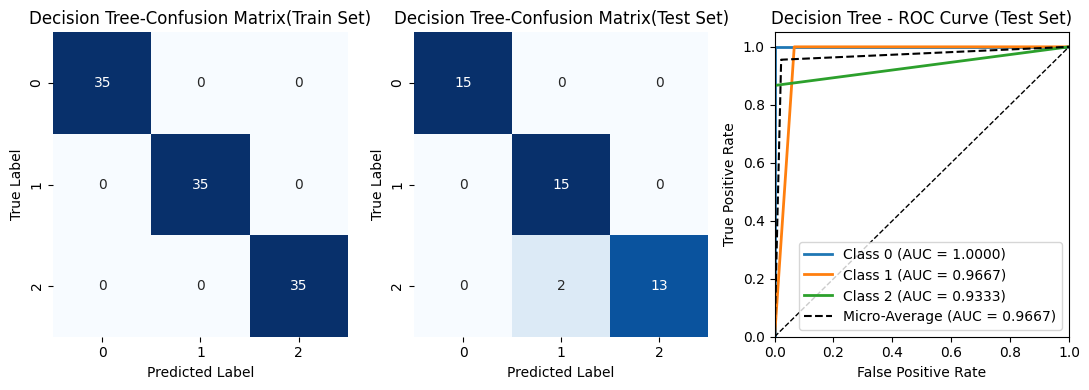

====== Random Forest ======
Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        35

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Train AUC: 1.000000
Test AUC: 0.994074
Train Specificity: 1.0000
Test Specificity: 0.9556


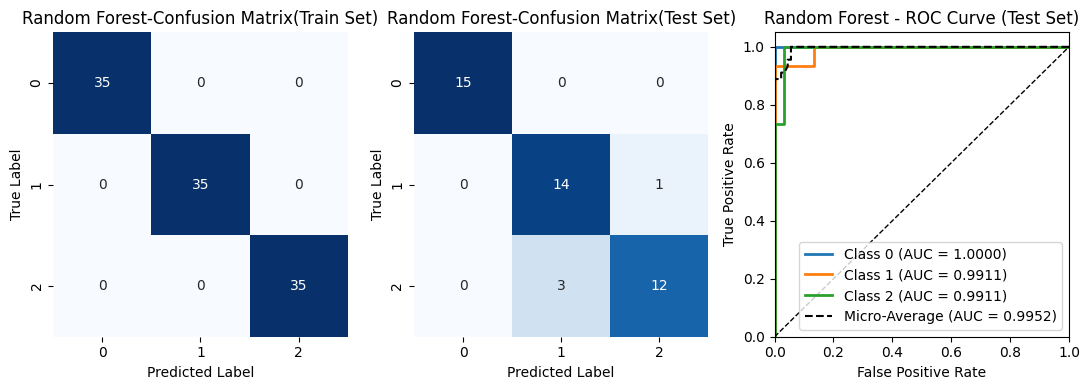

====== Bagging ======
Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        35

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

Train AUC: 1.000000
Test AUC: 0.996296
Train Specificity: 1.0000
Test Specificity: 0.9667


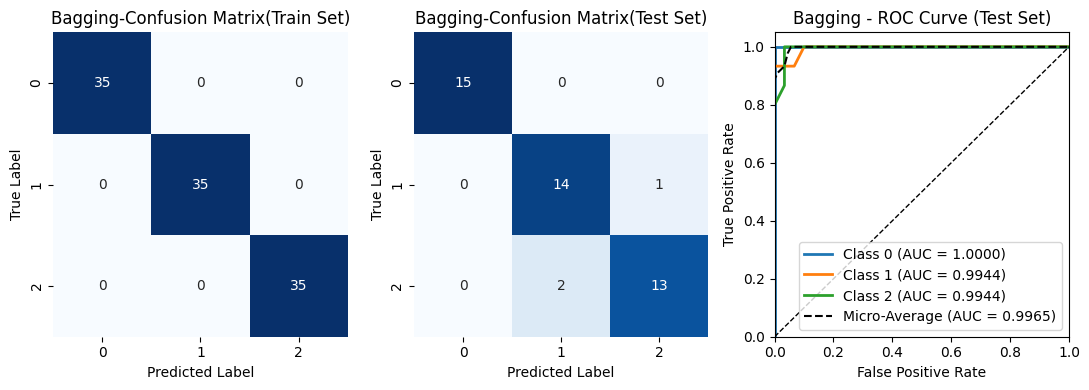

====== AdaBoost ======
Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        35

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

Train AUC: 1.000000
Test AUC: 0.980741
Train Specificity: 1.0000
Test Specificity: 0.9667


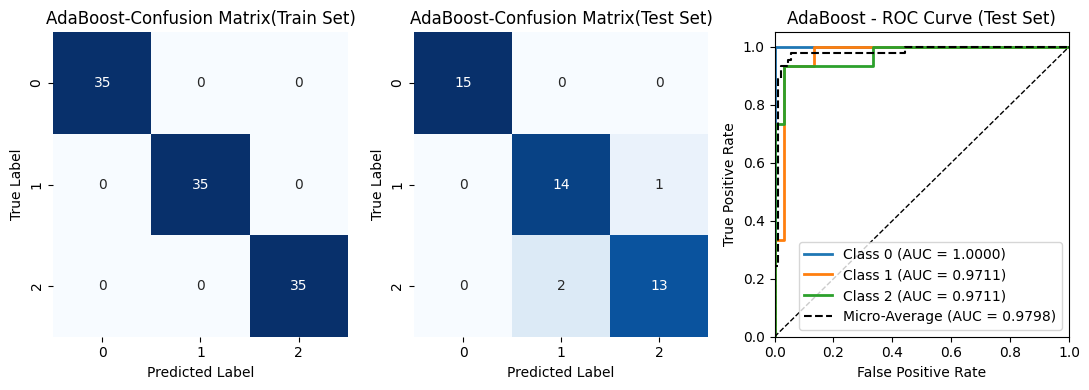

====== XGBoost ======
Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        35

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

Train AUC: 1.000000
Test AUC: 0.977037
Train Specificity: 1.0000
Test Specificity: 0.9667


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:13:38] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


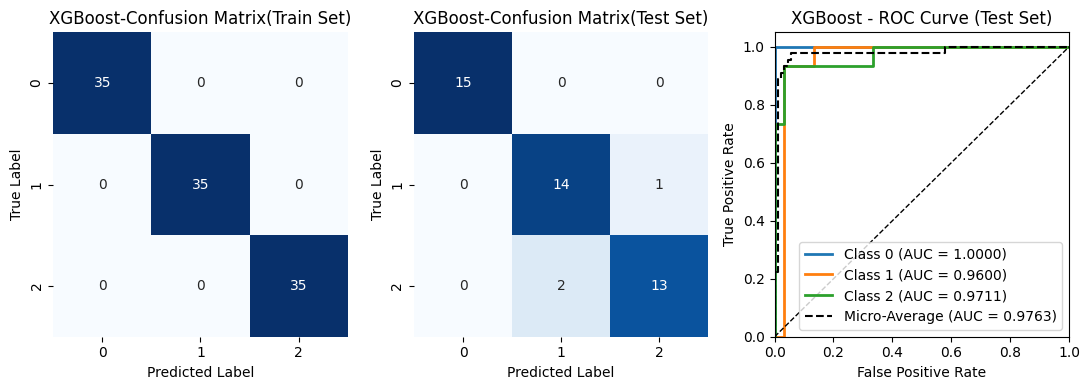

In [32]:
# 建立模型
models = {
  "Decision Tree": DecisionTreeClassifier(),
  "Random Forest": RandomForestClassifier(),
  "Bagging": BaggingClassifier(),
  "AdaBoost": AdaBoostClassifier(),
  "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# 訓練
for name, model in models.items():
  print(f"====== {name} ======")
  model.fit(X_train_scaled, y_train)
  evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, name)